# Mini Project: Malicious URL Classification (ฉบับแก้ป้ายข้อมูล)

จำแนก URL ออกเป็น 4 ประเภท ได้แก่ **benign / defacement / phishing / malware** จากข้อความ URL อย่างเดียว โดยไม่ต้องเปิดเว็บปลายทาง

| หัวข้อตามโจทย์ | ส่วนใน notebook |
|---|---|
| 1. Problem Definition | ส่วนที่ 1 |
| 2. Dataset | ส่วนที่ 2 |
| 3. Data Preprocessing | ส่วนที่ 3 (รวมการตรวจและแก้ป้ายที่ผิด) |
| 4. Machine Learning Model (≥ 2 โมเดล) | ส่วนที่ 4 (เทียบ 4 โมเดล) |
| 5. Model Evaluation | ส่วนที่ 5 |
| 6. Web Application | ส่วนที่ 6 (Streamlit: `app.py`) |
| 7. Discussion | ส่วนที่ 7 |
| References | ส่วนที่ 8 |

**โครงสร้างโฟลเดอร์**
```
data/     ข้อมูล Kaggle + ไฟล์อ้างอิง PhishStorm + ชุดทดสอบภายนอก
models/   โมเดลที่บันทึกแล้ว (สร้างโดย notebook นี้)
url_utils.py  ฟังก์ชันเตรียม URL และสกัดฟีเจอร์ (สร้างโดย notebook นี้ ใช้ร่วมกับ app.py)
app.py    Web Application (สร้างโดย notebook นี้)
```

## 1. Problem Definition

**ปัญหา:** URL อันตรายเป็นช่องทางหลักของการโจมตีทางไซเบอร์ ทั้งหลอกขโมยรหัสผ่าน (phishing), แจกจ่ายมัลแวร์ (malware) และเว็บที่ถูกเจาะแก้หน้า (defacement) ผู้ใช้ทั่วไปแยกด้วยตาได้ยาก

**เหตุผลที่เลือก:** ถ้าจำแนกได้จากข้อความ URL อย่างเดียว ระบบจะเร็ว (ไม่ต้องโหลดหน้าเว็บ), ปลอดภัย (ไม่ต้องเปิดลิงก์อันตราย) และนำไปใช้ในเบราว์เซอร์, อีเมล หรือแชตได้ทันที

**ประเภทของ Machine Learning:** **Classification แบบหลายคลาส (multi-class, 4 คลาส)** เรียนรู้แบบมีผู้สอน (supervised)

| คลาส | ความหมาย |
|---|---|
| benign | เว็บปกติ |
| defacement | หน้าเว็บของเว็บไซต์ที่ถูกเจาะแก้ไขหน้า |
| phishing | เว็บปลอมเพื่อหลอกเอาข้อมูล/รหัสผ่าน |
| malware | ลิงก์ที่แจกจ่ายไฟล์หรือโค้ดอันตราย |

In [1]:
import re, io, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tldextract
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer, MaxAbsScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 90)
SEED = 42
DATA, MODELS = Path("data"), Path("models")
MODELS.mkdir(exist_ok=True)
LABELS = ["benign", "defacement", "phishing", "malware"]

### ฟังก์ชันพื้นฐาน (`url_utils.py`)
เขียนเป็นไฟล์แยก เพื่อให้ **notebook กับ Web App ใช้ขั้นตอนเตรียมข้อมูลเดียวกันทุกประการ** (ถ้าเขียนไว้ใน notebook อย่างเดียว โมเดลที่บันทึกไว้จะโหลดใน `app.py` ไม่ได้)

- `normalize_url` ตัด `http://`, `https://` และ `www.` ออก ก่อนส่งให้โมเดล ในการทดลองรอบก่อนพบว่าถ้าไม่ตัด โมเดลจะเรียน **ทางลัด** เช่น "มี https = อันตราย" เพราะ URL ปกติใน Kaggle ส่วนใหญ่ไม่มี scheme
- `extract_lexical_features` สกัดฟีเจอร์เชิงโครงสร้าง 27 ตัว เช่น ความยาว จำนวนจุด การใช้ IP คำต้องสงสัย และ entropy

In [2]:
%%writefile url_utils.py
"""URL normalisation + 27 lexical features shared by the notebook and app.py (no network access)."""
import ipaddress, math, re
from collections import Counter
from urllib.parse import urlsplit
import numpy as np

_SCHEME = re.compile(r"^[A-Za-z][A-Za-z0-9+.-]*://")
_WWW = re.compile(r"^www\d*\.", re.IGNORECASE)
SUSPICIOUS_WORDS = ("login", "signin", "verify", "secure", "account", "update", "bank",
                    "password", "confirm", "wallet", "paypal", "invoice", "webscr")
SHORTENERS = {"bit.ly", "tinyurl.com", "t.co", "goo.gl", "ow.ly", "is.gd", "buff.ly", "adf.ly", "cutt.ly", "tiny.cc"}
FEATURE_NAMES = ["url_len", "host_len", "path_len", "query_len", "fragment_len", "subdomain_count", "path_depth",
                 "query_params", "digits", "letters", "special_chars", "dots", "hyphens", "slashes", "at_signs",
                 "percent", "equals", "underscores", "is_https", "has_ip", "has_port", "punycode", "non_ascii",
                 "shortener", "suspicious_word", "entropy", "host_digits"]


def normalize_url(value) -> str:
    """Remove scheme, leading www. and a lone trailing '/'."""
    text = _SCHEME.sub("", str(value).strip())
    text = _WWW.sub("", text)
    return text[:-1] if text.endswith("/") and text.count("/") == 1 else text


def normalize_urls(values) -> np.ndarray:
    return np.array([normalize_url(v) for v in np.asarray(values, dtype=object).ravel()], dtype=object)


def url_entropy(value: str) -> float:
    if not value:
        return 0.0
    counts, n = Counter(value), len(value)
    return float(-sum((c / n) * math.log2(c / n) for c in counts.values()))


def extract_one_url(value) -> list:
    raw = str(value)
    parse_value = raw if re.match(r"^[A-Za-z][A-Za-z0-9+.-]*://", raw) else f"http://{raw}"
    try:
        parts = urlsplit(parse_value)
        host, port = (parts.hostname or "").lower(), parts.port
    except ValueError:
        parts, host, port = urlsplit(""), "", None
    try:
        ipaddress.ip_address(host); has_ip = 1
    except ValueError:
        has_ip = 0
    host_parts = [p for p in host.split(".") if p]
    return [len(raw), len(host), len(parts.path), len(parts.query), len(parts.fragment),
            max(0, len(host_parts) - 2), sum(bool(p) for p in parts.path.split("/")),
            len([p for p in parts.query.split("&") if p]), sum(c.isdigit() for c in raw),
            sum(c.isalpha() for c in raw), sum(not c.isalnum() for c in raw), raw.count("."),
            raw.count("-"), raw.count("/"), raw.count("@"), raw.count("%"), raw.count("="), raw.count("_"),
            int(parts.scheme.lower() == "https"), has_ip, int(port is not None), int("xn--" in host),
            int(any(ord(c) > 127 for c in raw)), int(host in SHORTENERS),
            int(any(w in raw.lower() for w in SUSPICIOUS_WORDS)), url_entropy(raw), sum(c.isdigit() for c in host)]


def extract_lexical_features(values) -> np.ndarray:
    return np.asarray([extract_one_url(v) for v in np.asarray(values, dtype=object).ravel()], dtype=np.float32)


def host_of(value) -> str:
    text = value if re.match(r"^[A-Za-z][A-Za-z0-9+.-]*://", str(value)) else f"http://{value}"
    try:
        return (urlsplit(text).hostname or "").lower()
    except ValueError:
        return ""

Writing url_utils.py


In [3]:
import importlib, url_utils
importlib.reload(url_utils)
from url_utils import normalize_url, normalize_urls, extract_lexical_features, FEATURE_NAMES, host_of

example = "https://www.paypal.com.secure-login.example.tk/webscr?cmd=_login"
print("normalize :", normalize_url(example))
pd.DataFrame([extract_lexical_features([example])[0]], columns=FEATURE_NAMES).T.rename(columns={0: "value"}).head(27)

normalize : paypal.com.secure-login.example.tk/webscr?cmd=_login


,value
url_len,64.000000
host_len,38.000000
path_len,7.000000
query_len,10.000000
fragment_len,0.000000
subdomain_count,4.000000
path_depth,1.000000
query_params,1.000000
digits,0.000000
letters,51.000000


## 2. Dataset

**แหล่งข้อมูลหลัก:** [Malicious URLs dataset (Kaggle, Manu Siddhartha)](https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset) ไฟล์ `malicious_phish.csv`
ผู้เผยแพร่ระบุว่ารวบรวมมาจาก ISCX-URL-2016, Malware Domain Blacklist, Faizan's repo, PhishTank และ PhishStorm

| รายการ | รายละเอียด |
|---|---|
| จำนวนข้อมูล | 651,191 แถว |
| คอลัมน์ | `url` (ข้อความ URL), `type` (ป้ายคลาส) |
| Feature | ข้อความ URL → สร้างเป็น char n-gram TF-IDF + ฟีเจอร์เชิงโครงสร้าง 27 ตัว (ส่วนที่ 3.9) |
| Target | `type` ∈ {benign, defacement, phishing, malware} |

**ข้อมูลที่ใช้ตรวจสอบเพิ่มเติม (ไม่ได้ใช้เทรน)**
- `phishstorm_reference.csv`: ป้ายต้นฉบับของ PhishStorm ใช้ตรวจว่าการแก้ป้ายถูกต้อง
- `external_*.csv`: ชุดทดสอบภายนอกจากแหล่งอื่น ใช้วัดว่าโมเดลใช้กับข้อมูลต่างแหล่งได้แค่ไหน (DeepURLBench จาก Hugging Face, PhiUSIIL จาก UCI, OpenPhish และ URLhaus ซึ่งเป็น feed ภัยคุกคามจริงเดือน ก.ย. 2569)

shape: (651191, 2)


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=com_content&view=article&id=70&vsig70_0=15,defacement
4,http://adventure-nicaragua.net/index.php?option=com_mailto&tmpl=component&link=aHR0cDo...,defacement


,rows,percent
type,,
benign,428103,65.74
defacement,96457,14.81
phishing,94111,14.45
malware,32520,4.99


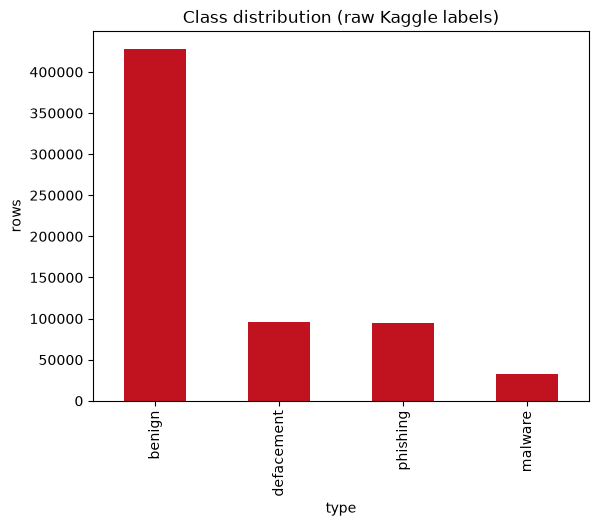

In [4]:
raw = pd.read_csv(DATA / "malicious_phish.csv")
print("shape:", raw.shape)
display(raw.head())
counts = raw["type"].value_counts()
display(counts.to_frame("rows").assign(percent=lambda d: (d.rows / d.rows.sum() * 100).round(2)))
counts.plot.bar(title="Class distribution (raw Kaggle labels)", color="#C1121F"); plt.ylabel("rows"); plt.show()

## 3. Data Preprocessing

### 3.1 Missing value / ค่าว่าง / ป้ายที่ไม่ถูกต้อง
ตรวจว่ามีช่องว่าง, URL ว่าง หรือป้ายที่ไม่อยู่ใน 4 คลาสหรือไม่

In [5]:
audit = {"raw_rows": len(raw),
         "missing_url": int(raw["url"].isna().sum()),
         "missing_type": int(raw["type"].isna().sum()),
         "empty_url": int(raw["url"].astype(str).str.strip().eq("").sum()),
         "invalid_label": int((~raw["type"].isin(LABELS)).sum()),
         "exact_duplicate_rows": int(raw.duplicated(["url", "type"]).sum())}
audit

{'raw_rows': 651191,
 'missing_url': 0,
 'missing_type': 0,
 'empty_url': 0,
 'invalid_label': 0,
 'exact_duplicate_rows': 10066}

### 3.2 ตรวจคุณภาพป้าย (Label audit): พบป้ายสลับกัน

ใน [Kaggle discussion ของชุดข้อมูลนี้](https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset/discussion/431505) มีผู้ใช้พบว่าเว็บปกติอย่าง `python.org` และ `apache.org` ถูกติดป้าย phishing และมีคนชี้ว่าผู้สร้างเอาข้อมูล **PhishStorm** มาต่อท้ายไฟล์โดย **สลับป้าย 0/1**

วิธีตรวจของเรา: หา "ก้อน" ของป้ายเดียวกันที่เรียงต่อกันยาว ๆ ในไฟล์ แล้วดูตัวอย่าง URL ในแต่ละก้อน

In [6]:
run_id = (raw["type"] != raw["type"].shift()).cumsum()
runs = raw.groupby(run_id).agg(start=("type", lambda s: s.index[0]), end=("type", lambda s: s.index[-1]),
                               label=("type", "first"), rows=("type", "size"))
runs[runs.rows >= 5000].tail(6)

,start,end,label,rows
type,,,,
222201,520330,535218,phishing,14889
222202,535219,555185,malware,19967
222203,555186,573416,benign,18231
222209,573511,603181,benign,29671
222210,603182,651190,phishing,48009


In [7]:
print("ท้ายก้อน malware -> ต้นก้อน 'benign' (แถว 555,186 เป็นต้นไป)")
display(raw.iloc[555183:555191])
print("รอยต่อ 'benign' -> 'phishing' (แถว 603,182 เป็นต้นไป)")
display(raw.iloc[603178:603188])

ท้ายก้อน malware -> ต้นก้อน 'benign' (แถว 555,186 เป็นต้นไป)


,url,type
555183,http://219.155.142.211:55621/Mozi.m,malware
555184,http://42.238.164.8:48848/Mozi.m,malware
555185,http://172.36.45.82:41684/Mozi.m,malware
555186,nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/...,benign
555187,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_home-customer&nav=1/loading.php,benign
555188,serviciosbys.com/paypal.cgi.bin.get-into.herf.secure.dispatch35463256rzr321654641dsf65...,benign
555189,mail.printakid.com/www.online.americanexpress.com/index.html,benign
555190,thewhiskeydregs.com/wp-content/themes/widescreen/includes/temp/promocoessmiles/?847847...,benign


รอยต่อ 'benign' -> 'phishing' (แถว 603,182 เป็นต้นไป)


,url,type
603178,www.idxband.com/telin/images/e-online.php,benign
603179,www.coffeewithsophieinc.com/media/system/js/cadastroempresarial2.1.php/,benign
603180,conseguircreditos.webs.tl/,benign
603181,www.vbacreation.fr/includes/Archive/Connect/SignOn.php,benign
603182,www.sec.gov/edgar.shtml,phishing
603183,www.taxsites.com/associations2.html,phishing
603184,www.crescan.com/pakistanicma/,phishing
603185,www.ficpa.org/content/home.aspx,phishing
603186,pacioli.loyola.edu/aecm/,phishing
603187,www.financialaccounting.com/financialprof.htm,phishing


**สิ่งที่เห็น**
- แถว **555,186–603,181** ติดป้าย `benign` แต่ URL เป็น phishing ชัดเจน เช่น `paypal.co.uk/cycgi-bin/webscr...`, `login.SkyPe.com/.../verification`
- แถว **603,182–651,190** ติดป้าย `phishing` แต่เป็นเว็บปกติ เช่น `www.sec.gov/edgar.shtml` และมี **48,009 แถวพอดี** เท่ากับจำนวน URL ปกติใน PhishStorm ต้นฉบับ

### 3.3 แก้ป้าย
สลับป้ายเฉพาะในสองช่วงนี้ แถวอื่นไม่แตะ และเก็บป้ายเดิมไว้ในคอลัมน์ `type_orig` เพื่อใช้ทดลองเปรียบเทียบในส่วนที่ 5

In [8]:
A0, A1, B0, B1 = 555_186, 603_181, 603_182, 651_190
assert runs[(runs.start == B0) & (runs.end == B1)].rows.iloc[0] == 48_009   # matches PhishStorm's legitimate count

df = raw.copy()
df["row"] = df.index
df["type_orig"] = df["type"]
fix_a = df.row.between(A0, A1) & df.type_orig.eq("benign")      # really phishing
fix_b = df.row.between(B0, B1) & df.type_orig.eq("phishing")    # really legitimate
df.loc[fix_a, "type"] = "phishing"
df.loc[fix_b, "type"] = "benign"
df["phishstorm_block"] = df.row.between(A0, B1)
audit.update(relabel_benign_to_phishing=int(fix_a.sum()), relabel_phishing_to_benign=int(fix_b.sum()))
print(f"benign -> phishing : {fix_a.sum():,}")
print(f"phishing -> benign : {fix_b.sum():,}")
print(f"รวมป้ายที่แก้      : {(fix_a | fix_b).sum():,} แถว = {(fix_a | fix_b).mean():.1%} ของทั้งไฟล์")
print(f"สัดส่วนป้าย phishing เดิมที่ผิด: {fix_b.sum() / (raw.type == 'phishing').sum():.1%}")
pd.crosstab(df.type_orig, df.type, margins=True)

benign -> phishing : 47,904
phishing -> benign : 48,009
รวมป้ายที่แก้      : 95,913 แถว = 14.7% ของทั้งไฟล์
สัดส่วนป้าย phishing เดิมที่ผิด: 51.0%


type,benign,defacement,malware,phishing,All
type_orig,,,,,
benign,380199,0,0,47904,428103
defacement,0,96457,0,0,96457
malware,0,0,32520,0,32520
phishing,48009,0,0,46102,94111
All,428208,96457,32520,94006,651191


### 3.4 ตรวจการแก้ป้ายกับ PhishStorm ต้นฉบับ
เทียบ URL (ตัวพิมพ์เล็ก ตัดช่องว่าง) กับไฟล์อ้างอิงที่มีป้ายถูกต้อง ([Corrected Phishing URLs Dataset](https://www.kaggle.com/datasets/sslliiman/phishstorm-phishing-legitimate-url-dataset)) ไฟล์นี้ **ใช้ตรวจอย่างเดียว ไม่ได้นำไปเทรน**

In [9]:
ref_path = DATA / "phishstorm_reference.csv"
if ref_path.exists():
    ref = pd.read_csv(ref_path, usecols=[0, 1], encoding_errors="replace")
    ref.columns = ["url", "ref_label"]
    ref["key"] = ref.url.astype(str).str.strip().str.lower()
    ref = ref.drop_duplicates("key")
    m = df.assign(key=df.url.astype(str).str.strip().str.lower()).merge(ref[["key", "ref_label"]], on="key")
    inside = m[m.phishstorm_block]
    verify = pd.DataFrame({
        "matched rows": [len(inside), len(m) - len(inside)],
        "original label agrees": [(inside.type_orig == inside.ref_label).mean(), (m[~m.phishstorm_block].type_orig == m[~m.phishstorm_block].ref_label).mean()],
        "fixed label agrees": [(inside.type == inside.ref_label).mean(), (m[~m.phishstorm_block].type == m[~m.phishstorm_block].ref_label).mean()]},
        index=["inside fixed block", "outside block"])
    display(verify.style.format({"original label agrees": "{:.2%}", "fixed label agrees": "{:.2%}"}))
else:
    print("ไม่พบไฟล์อ้างอิง - ข้ามขั้นตอนตรวจ")

,matched rows,original label agrees,fixed label agrees
inside fixed block,95912,0.00%,100.00%
outside block,6,100.00%,100.00%


**ผล:** ในช่วงที่แก้ ป้ายเดิมตรงกับต้นฉบับ **0%** (ผิดทุกแถว) ส่วนป้ายที่แก้แล้วตรง **100%** นอกช่วงนี้มี URL ของ PhishStorm แค่ไม่กี่แถว และป้ายถูกอยู่แล้ว

### 3.5 ทำความสะอาดข้อความ (Duplicate / conflict / control character)
ลำดับขั้น (บันทึกจำนวนแถวทุกขั้นในตาราง `clean_log`)
1. ตัดแถวที่ป้ายไม่อยู่ใน 4 คลาส และ URL ว่าง
2. ตัดแถวที่มี control character: เป็นแถวขยะ เช่นข้อความที่ปนอักขระเสียในช่วง PhishStorm
3. สร้าง `norm` = URL ที่ตัด scheme/`www.` แล้ว เพราะ `http://a.com` กับ `a.com` คือหน้าเดียวกัน
4. ตัด URL ที่มี **มากกว่า 1 ป้าย** (หลัง normalize) ทิ้งทุกแถว เพราะตัดสินไม่ได้ว่าป้ายไหนถูก
5. ตัด URL ซ้ำ (เก็บแถวเดียว)

In [10]:
clean_log = [("start", len(df))]
df = df[df["type"].isin(LABELS)].copy()
df["url"] = df["url"].astype(str).str.strip()
df = df[df.url.ne("")];                                                     clean_log.append(("valid label & non-empty url", len(df)))
df = df[~df.url.str.contains(r"[\x00-\x1F\x7F-\x9F]", regex=True)];          clean_log.append(("drop control characters", len(df)))
df["norm"] = normalize_urls(df.url)
conflict = df.groupby("norm")["type"].transform("nunique").gt(1) | df.groupby("norm")["type_orig"].transform("nunique").gt(1)
df = df[~conflict];                                                         clean_log.append(("drop URLs with conflicting labels", len(df)))
df = df.drop_duplicates("norm");                                            clean_log.append(("drop duplicate URLs", len(df)))
pd.DataFrame(clean_log, columns=["step", "rows"]).assign(removed=lambda d: -d.rows.diff().fillna(0).astype(int))

,step,rows,removed
0,start,651191,0
1,valid label & non-empty url,651191,0
2,drop control characters,651089,102
3,drop URLs with conflicting labels,642853,8236
4,drop duplicate URLs,630867,11986


### 3.6 กันข้อมูลรั่ว: ตัดโดเมนที่อยู่ในชุดทดสอบภายนอก
หาโดเมนหลัก (registered domain เช่น `mail.google.com` → `google.com`) ด้วย `tldextract` แบบ offline แล้ว **ตัดทุกแถวที่มีโดเมนเดียวกับชุดทดสอบภายนอก** ออกจากข้อมูลเทรน เพื่อให้ผลทดสอบภายนอกวัดกับเว็บที่โมเดลไม่เคยเห็นจริง ๆ

In [11]:
ext = tldextract.TLDExtract(suffix_list_urls=())      # bundled public-suffix list, no network
_cache = {}
def registered_domain(host):
    if host not in _cache:
        _cache[host] = ext(host).top_domain_under_public_suffix or host
    return _cache[host]

df["host"] = df.url.map(host_of)
df = df[df.host.ne("")]
df["registered_domain"] = df.host.map(registered_domain)

external = {name: pd.read_csv(DATA / f"external_{name}.csv") for name in ["deepurlbench_60k", "phiusiil_10k", "openphish", "urlhaus_latest"]}
held = set()
for d in external.values():
    held |= {registered_domain(h) for h in d.url.map(host_of) if h}
before = len(df)
df = df[~df.registered_domain.isin(held)]
clean_log.append(("drop domains used by external test sets", len(df)))
print(f"external-test domains: {len(held):,} | rows removed: {before - len(df):,} | rows left: {len(df):,}")

external-test domains: 69,453 | rows removed: 10,230 | rows left: 620,637


### 3.7 จัดสมดุลข้อมูล และคุมทางลัด
- **ไม่เกิน 20 URL ต่อโดเมนต่อคลาส:** กันไม่ให้เว็บเดียวที่มีหลายพัน URL ครอบงำคลาส และทำให้โมเดลแค่จำชื่อโดเมน
- **จำกัดคลาสละไม่เกิน 100,000 แถว:** benign มีมากกว่าคลาสอื่นหลายเท่า
- **โดเมนเปล่า 25% ต่อคลาส:** โดเมนเปล่าคือ URL ที่มีแค่ชื่อเว็บ ไม่มี path เช่น `example.com` ในรอบทดลองก่อน ถ้าสัดส่วนนี้ต่างกันมากระหว่างคลาส โมเดลจะเรียนทางลัดว่า "โดเมนเปล่า = เว็บปกติ" จึงคุมให้เท่ากันเท่าที่ข้อมูลมี (malware และ defacement มีโดเมนเปล่าน้อยมาก)

In [12]:
TARGET, BARE_SHARE, PER_DOMAIN = 100_000, 0.25, 20
df = df.sample(frac=1, random_state=SEED)
df = df[df.groupby(["type", "registered_domain"]).cumcount() < PER_DOMAIN]
df["bare"] = ~df.norm.str.contains(r"[/?#]", regex=True)

parts = []
for cls in LABELS:
    c = df[df["type"] == cls]
    n_bare = min(int(c.bare.sum()), int(TARGET * BARE_SHARE))
    n_path = min(int((~c.bare).sum()), TARGET - n_bare)
    if n_path < TARGET - n_bare:                                    # not enough path URLs: keep the 25% ratio if possible
        n_bare = min(int(c.bare.sum()), int(n_path * BARE_SHARE / (1 - BARE_SHARE)))
    parts += [c[c.bare].head(n_bare), c[~c.bare].head(n_path)]
data = pd.concat(parts, ignore_index=True)
summary = data.groupby("type").agg(rows=("url", "size"), bare_share=("bare", "mean"), domains=("registered_domain", "nunique"))
display(summary.style.format({"bare_share": "{:.1%}"}))
print("total rows:", len(data))

,rows,bare_share,domains
type,,,
benign,100000,25.0%,57242
defacement,33074,0.0%,2122
malware,15898,6.3%,7050
phishing,64816,25.0%,37081


total rows: 213788


### 3.8 แบ่ง Train/Test ตามโดเมน (Group split)
ใช้ `StratifiedGroupKFold` (5 fold แล้วเลือก fold เดียวเป็น test ≈ 20%):
- **Group = registered domain:** URL ทุกตัวของเว็บเดียวกันอยู่ฝั่งเดียวกัน ถ้าสุ่มแบ่งแบบธรรมดา URL จากเว็บเดียวกันจะอยู่ทั้งใน train และ test ทำให้คะแนนสูงเกินจริง
- **Stratify = คลาส + โดเมนเปล่า:** สัดส่วนคลาสใน train/test ใกล้เคียงกัน

In [13]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
strat = data["type"] + "|" + data.bare.astype(str)
train_idx, test_idx = next(sgkf.split(data, strat, data.registered_domain))
data["split"] = "train"
data.loc[test_idx, "split"] = "test"
train, test = data[data.split == "train"].reset_index(drop=True), data[data.split == "test"].reset_index(drop=True)
assert not set(train.registered_domain) & set(test.registered_domain), "domain leakage!"
print("ไม่มีโดเมนซ้ำระหว่าง train และ test ✓")
pd.crosstab(data["type"], data.split, margins=True)

ไม่มีโดเมนซ้ำระหว่าง train และ test ✓


split,test,train,All
type,,,
benign,20000,80000,100000
defacement,6614,26460,33074
malware,3180,12718,15898
phishing,12964,51852,64816
All,42758,171030,213788


### 3.9 Feature: Encoding, Scaling และ Feature Selection
URL เป็นข้อความ จึงแปลงเป็นตัวเลขสองแบบแล้วต่อกัน (`FeatureUnion`)

| ส่วน | ทำอะไร | ตรงกับหัวข้อในโจทย์ |
|---|---|---|
| **char n-gram TF-IDF (2–5 ตัวอักษร)** | ตัด URL เป็นชิ้นตัวอักษรยาว 2–5 ตัว เช่น `log`, `.php`, `paypa` แล้วให้น้ำหนักตามความถี่ (TF-IDF) | Encoding |
| `min_df=5`, `max_features=200,000` | เก็บเฉพาะ n-gram ที่พบอย่างน้อย 5 URL และเอาแค่ 200,000 ตัวที่พบบ่อยที่สุด | Feature Selection |
| **ฟีเจอร์เชิงโครงสร้าง 27 ตัว** | ความยาว จุด IP คำต้องสงสัย entropy ฯลฯ (`url_utils.py`) | Feature Engineering |
| `MaxAbsScaler` | ปรับฟีเจอร์เชิงโครงสร้างให้อยู่ในช่วง [-1, 1] โดยไม่ทำลายความเบาบาง (sparse) ของเมทริกซ์ | Scaling |
| `lexical weight` | ตัวคูณน้ำหนักฟีเจอร์เชิงโครงสร้างเทียบกับ n-gram | Hyperparameter |

ทุกขั้นอยู่ใน `Pipeline` เดียว จึง fit เฉพาะบนข้อมูล train (กันข้อมูลรั่วระหว่าง CV) และใน Web App ก็เรียก `model.predict(url)` ได้เลย

In [14]:
def tfidf():
    return TfidfVectorizer(analyzer="char", ngram_range=(2, 5), min_df=5, max_features=200_000,
                           sublinear_tf=True, lowercase=False, dtype=np.float32)

def hybrid(clf, lex_weight=2.0):
    # normalise -> [char TF-IDF | 27 lexical features (scaled) x weight] -> classifier
    lexical = Pipeline([("extract", FunctionTransformer(extract_lexical_features)), ("scale", MaxAbsScaler())])
    return Pipeline([("normalize", FunctionTransformer(normalize_urls)),
                     ("features", FeatureUnion([("char_tfidf", tfidf()), ("lexical", lexical)],
                                               transformer_weights={"lexical": lex_weight})),
                     ("classifier", clf)])

def candidates(C_svc=0.25, C_lr=4.0):
    return {
        "LinearSVC": hybrid(LinearSVC(C=C_svc, class_weight="balanced", max_iter=10_000, random_state=SEED)),
        "LogisticRegression": hybrid(LogisticRegression(C=C_lr, class_weight="balanced", solver="saga", max_iter=1000, tol=1e-3, random_state=SEED)),
        "ComplementNB": Pipeline([("normalize", FunctionTransformer(normalize_urls)), ("char_tfidf", tfidf()),
                                  ("classifier", ComplementNB(alpha=0.1))]),
        "RandomForest": Pipeline([("normalize", FunctionTransformer(normalize_urls)),
                                  ("lexical", FunctionTransformer(extract_lexical_features)),
                                  ("classifier", RandomForestClassifier(n_estimators=200, min_samples_leaf=2, class_weight="balanced",
                                                                        n_jobs=-1, random_state=SEED))]),
    }

## 4. Machine Learning Model

เปรียบเทียบ 4 โมเดล (โจทย์กำหนดอย่างน้อย 2)

| โมเดล | ฟีเจอร์ | เหตุผลที่เลือก |
|---|---|---|
| **LinearSVC** | TF-IDF + lexical | เหมาะกับข้อมูลข้อความที่มีฟีเจอร์มาก (200k) และ sparse เร็วมาก |
| **Logistic Regression** | TF-IDF + lexical | เส้นแบ่งเชิงเส้นเหมือน SVM แต่ **ให้ค่าความน่าจะเป็น** ได้ |
| **Complement Naive Bayes** | TF-IDF | baseline ที่เร็วที่สุดสำหรับข้อความ (ต้องใช้ฟีเจอร์ที่ไม่ติดลบ จึงใช้แค่ TF-IDF) |
| **Random Forest** | lexical 27 ตัว | โมเดลต้นไม้แบบไม่เชิงเส้น (ใช้กับเมทริกซ์ 200k คอลัมน์ได้ช้าและไม่ดี จึงใช้แค่ฟีเจอร์เชิงโครงสร้าง) |

ทุกโมเดลใช้ `class_weight="balanced"` (ยกเว้น NB ที่ไม่รองรับ) เพื่อให้คลาสเล็ก (malware, defacement) มีน้ำหนักพอ

### 4.1 Cross-validation บนข้อมูล train
ใช้ **3-fold StratifiedGroupKFold (group = โดเมน)** บนข้อมูล train ที่สุ่มย่อยคลาสละไม่เกิน 12,000 แถว เพื่อให้รันเร็ว ส่วน test เก็บไว้ใช้ครั้งเดียวตอนท้าย

In [15]:
cv_data = train.sample(frac=1, random_state=SEED)
cv_data = cv_data[cv_data.groupby("type").cumcount() < 12_000].reset_index(drop=True)
cv = list(StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED).split(
    cv_data, cv_data["type"] + "|" + cv_data.bare.astype(str), cv_data.registered_domain))
Xcv, ycv = cv_data.url.to_numpy(dtype=object), cv_data["type"].to_numpy()

def run_cv(model):
    s = cross_validate(model, Xcv, ycv, cv=cv, scoring={"macro_f1": "f1_macro", "accuracy": "accuracy"}, n_jobs=3)
    return s["test_macro_f1"].mean(), s["test_macro_f1"].std(), s["test_accuracy"].mean(), s["fit_time"].mean()

cv_rows = []
for name, model in candidates().items():
    f1m, f1s, acc, ft = run_cv(model)
    cv_rows.append({"model": name, "cv_macro_f1": f1m, "cv_std": f1s, "cv_accuracy": acc, "fit_sec": ft})
cv_table = pd.DataFrame(cv_rows).sort_values("cv_macro_f1", ascending=False)
cv_table.style.format({"cv_macro_f1": "{:.4f}", "cv_std": "{:.4f}", "cv_accuracy": "{:.4f}", "fit_sec": "{:.1f}"})

,model,cv_macro_f1,cv_std,cv_accuracy,fit_sec
0,LinearSVC,0.8741,0.0040,0.8716,14.8
1,LogisticRegression,0.8732,0.0039,0.8709,25.3
2,ComplementNB,0.8379,0.0019,0.8349,8.5
3,RandomForest,0.7680,0.0028,0.7634,4.7


### 4.2 Hyperparameter tuning (ค่า C ของสองโมเดลเชิงเส้น)
**C** คือความแรงของการลงโทษเมื่อทายผิดใน train
- C ต่ำ: เส้นแบ่งเรียบ กันการจำข้อมูล (overfit)
- C สูง: พยายามทายถูกทุกแถวใน train

สำหรับ LinearSVC กับ Logistic Regression ค่า C มีผลต่อเส้นแบ่งต่างกัน ช่วงที่เหมาะจึงต่างกัน

In [16]:
tune_rows = []
for C in [0.1, 0.25, 1.0]:
    f1m, f1s, acc, _ = run_cv(candidates(C_svc=C)["LinearSVC"])
    tune_rows.append({"model": "LinearSVC", "C": C, "cv_macro_f1": f1m, "cv_std": f1s})
for C in [1.0, 4.0, 16.0]:
    f1m, f1s, acc, _ = run_cv(candidates(C_lr=C)["LogisticRegression"])
    tune_rows.append({"model": "LogisticRegression", "C": C, "cv_macro_f1": f1m, "cv_std": f1s})
tune_table = pd.DataFrame(tune_rows)
best_C = tune_table.loc[tune_table.groupby("model").cv_macro_f1.idxmax()].set_index("model").C.to_dict()
display(tune_table.style.format({"cv_macro_f1": "{:.4f}", "cv_std": "{:.4f}"}))
print("best C:", best_C)

,model,C,cv_macro_f1,cv_std
0,LinearSVC,0.100000,0.8677,0.0034
1,LinearSVC,0.250000,0.8741,0.0040
2,LinearSVC,1.000000,0.8733,0.0038
3,LogisticRegression,1.000000,0.8683,0.0037
4,LogisticRegression,4.000000,0.8732,0.0039
5,LogisticRegression,16.000000,0.8735,0.0045


best C: {'LinearSVC': 0.25, 'LogisticRegression': 16.0}


### 4.3 เทรนทั้ง 4 โมเดลบน train เต็ม
ใช้ค่า C ที่ดีที่สุดจาก 4.2 จับเวลาเทรน เวลาทำนายต่อ URL และขนาดไฟล์โมเดล

In [17]:
Xtr, ytr = train.url.to_numpy(dtype=object), train["type"].to_numpy()
Xte, yte = test.url.to_numpy(dtype=object), test["type"].to_numpy()
models, cost = {}, {}
for name, model in candidates(C_svc=best_C["LinearSVC"], C_lr=best_C["LogisticRegression"]).items():
    t0 = time.time(); model.fit(Xtr, ytr); fit_sec = time.time() - t0
    t0 = time.time(); model.predict(Xte[:5000]); ms = (time.time() - t0) / 5000 * 1000
    buf = io.BytesIO(); joblib.dump(model, buf, compress=3)
    models[name], cost[name] = model, {"fit_sec": fit_sec, "ms_per_url": ms, "size_mb": buf.tell() / 1e6}
    print(f"{name:20s} fit {fit_sec:6.1f}s  predict {ms:.3f} ms/url  size {buf.tell()/1e6:.1f} MB")

LinearSVC            fit   81.6s  predict 0.099 ms/url  size 7.3 MB


LogisticRegression   fit  234.7s  predict 0.086 ms/url  size 4.7 MB


ComplementNB         fit   46.2s  predict 0.055 ms/url  size 11.0 MB


RandomForest         fit   18.8s  predict 0.080 ms/url  size 99.8 MB


## 5. Model Evaluation

**Metric ที่ใช้และเหตุผล**
- **Macro F1 (ตัวหลัก):** เฉลี่ย F1 ของทุกคลาสโดยให้น้ำหนักเท่ากัน คลาสเล็กอย่าง malware จึงมีความสำคัญเท่า benign ส่วน Accuracy จะถูกคลาสใหญ่ดึงให้ดูดีเกินจริง
- **Precision / Recall / F1 รายคลาส:** Recall ของคลาสอันตรายคือจับภัยได้กี่ % ส่วน Precision คือแจ้งเตือนแล้วถูกกี่ %
- **benign false alert:** สัดส่วน URL ปกติที่ถูกแจ้งเตือนผิด ถ้าสูง ผู้ใช้จะรำคาญและเลิกเชื่อระบบ
- **Confusion Matrix:** ดูว่าคลาสไหนถูกทายสลับกับคลาสไหน

### 5.1 ผลบน Test ภายใน

In [18]:
def evaluate(y_true, y_pred, labels=LABELS):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ben = y_true == "benign"
    return {"accuracy": accuracy_score(y_true, y_pred),
            "macro_precision": p.mean(), "macro_recall": r.mean(),
            "macro_f1": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
            "benign_false_alert": (y_pred[ben] != "benign").mean() if ben.any() else np.nan}

preds = {name: m.predict(Xte) for name, m in models.items()}
result = pd.DataFrame({name: {**evaluate(yte, p), **cost[name]} for name, p in preds.items()}).T.sort_values("macro_f1", ascending=False)
result.style.format({"accuracy": "{:.4f}", "macro_precision": "{:.4f}", "macro_recall": "{:.4f}", "macro_f1": "{:.4f}",
                     "benign_false_alert": "{:.2%}", "fit_sec": "{:.1f}", "ms_per_url": "{:.3f}", "size_mb": "{:.1f}"})

,accuracy,macro_precision,macro_recall,macro_f1,benign_false_alert,fit_sec,ms_per_url,size_mb
LinearSVC,0.9038,0.9267,0.8744,0.8976,4.08%,81.6,0.099,7.3
LogisticRegression,0.9019,0.9188,0.8774,0.8960,5.75%,234.7,0.086,4.7
ComplementNB,0.8623,0.8954,0.8186,0.8506,4.04%,46.2,0.055,11.0
RandomForest,0.7698,0.7796,0.7747,0.7757,21.84%,18.8,0.080,99.8


In [19]:
per_class = []
for name, p in preds.items():
    pr, rc, f1, sup = precision_recall_fscore_support(yte, p, labels=LABELS, zero_division=0)
    per_class += [{"model": name, "class": c, "precision": a, "recall": b, "f1": d, "support": s} for c, a, b, d, s in zip(LABELS, pr, rc, f1, sup)]
pd.DataFrame(per_class).pivot(index="model", columns="class", values="f1")[LABELS].style.format("{:.3f}").set_caption("F1 per class")

class,benign,defacement,phishing,malware
model,,,,
ComplementNB,0.885,0.814,0.848,0.856
LinearSVC,0.917,0.878,0.895,0.900
LogisticRegression,0.915,0.878,0.893,0.898
RandomForest,0.782,0.755,0.747,0.819


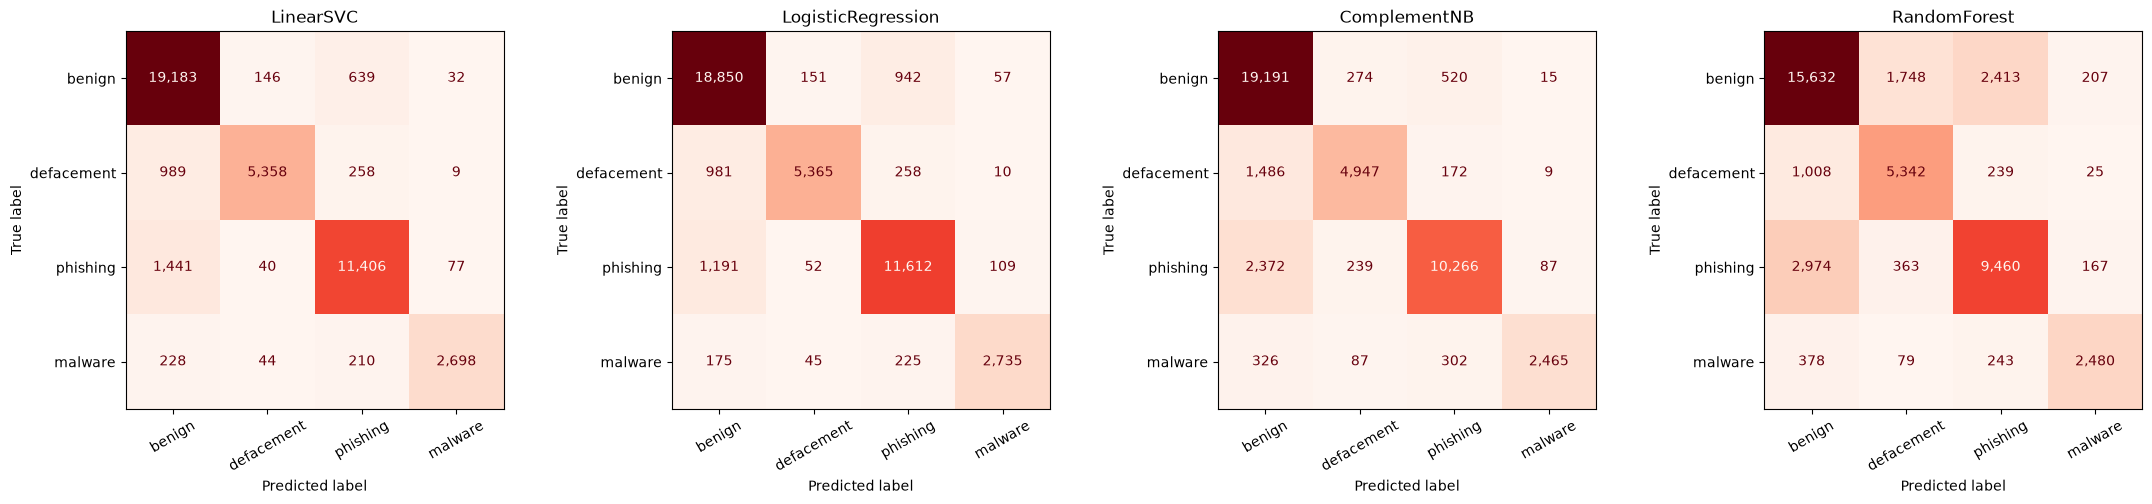

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, p) in zip(axes, preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(yte, p, labels=LABELS), display_labels=LABELS).plot(ax=ax, cmap="Reds", colorbar=False, values_format=",")
    ax.set_title(name); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

### 5.2 เลือกโมเดลสุดท้าย
**เกณฑ์ที่ตั้งไว้ก่อนดูผล:** เลือกโมเดลที่ Macro F1 บน test สูงสุด ถ้ามีโมเดลที่ต่างจากอันดับหนึ่งไม่เกิน 0.005 ให้เลือก **Logistic Regression** เพราะให้ค่าความน่าจะเป็นที่แสดงใน Web App ได้ (ตามข้อ "แสดงความหมายของผลลัพธ์")

In [21]:
top = result.index[0]
lr_gap = result.loc[top, "macro_f1"] - result.loc["LogisticRegression", "macro_f1"]
FINAL = "LogisticRegression" if lr_gap <= 0.005 else top
final_model = models[FINAL]
print(f"best macro F1: {top} ({result.loc[top, 'macro_f1']:.4f}) | LogisticRegression gap = {lr_gap:.4f}")
print("FINAL MODEL  :", FINAL)
print()
print(classification_report(yte, preds[FINAL], labels=LABELS, digits=3))

best macro F1: LinearSVC (0.8976) | LogisticRegression gap = 0.0016
FINAL MODEL  : LogisticRegression

              precision    recall  f1-score   support

      benign      0.889     0.943     0.915     20000
  defacement      0.956     0.811     0.878      6614
    phishing      0.891     0.896     0.893     12964
     malware      0.940     0.860     0.898      3180

    accuracy                          0.902     42758
   macro avg      0.919     0.877     0.896     42758
weighted avg      0.904     0.902     0.901     42758



### 5.3 ผลของการแก้ป้าย (Ablation)
เทรนโมเดลสุดท้ายซ้ำด้วย **ป้ายเดิมที่ผิด** บน URL ชุดเดิมทุกแถว แล้ววัดบน test ชุดเดียวกัน (ป้ายที่แก้แล้ว) ความต่างของผลจึงมาจากป้ายอย่างเดียว

In [22]:
from sklearn.base import clone
orig_model = clone(final_model).fit(Xtr, train["type_orig"].to_numpy())
p_orig = orig_model.predict(Xte)
ps = test.phishstorm_block.to_numpy()
ablation = pd.DataFrame({
    "original labels": {**evaluate(yte, p_orig), "macro_f1_phishstorm_rows": f1_score(yte[ps], p_orig[ps], labels=["benign", "phishing"], average="macro")},
    "fixed labels": {**evaluate(yte, preds[FINAL]), "macro_f1_phishstorm_rows": f1_score(yte[ps], preds[FINAL][ps], labels=["benign", "phishing"], average="macro")},
}).T[["accuracy", "macro_f1", "benign_false_alert", "macro_f1_phishstorm_rows"]]
ablation.style.format({"accuracy": "{:.4f}", "macro_f1": "{:.4f}", "benign_false_alert": "{:.2%}", "macro_f1_phishstorm_rows": "{:.4f}"})

,accuracy,macro_f1,benign_false_alert,macro_f1_phishstorm_rows
original labels,0.6986,0.7500,19.77%,0.2005
fixed labels,0.9019,0.8960,5.75%,0.9397


### 5.4 ทดสอบกับข้อมูลภายนอก (ต่างแหล่ง ไม่เคยเห็น)
ชุดภายนอกมีคลาสไม่ครบ 4 คลาส และไม่มี defacement เลย จึงรายงานเป็น recall รายคลาส (ตารางแบ่งเป็น % ของแต่ละแถว) แทนการเทียบ Macro F1 กับ test ภายในตรง ๆ

| ชุด | คลาสที่มี | ที่มา |
|---|---|---|
| DeepURLBench 60k | benign / phishing / malware | Hugging Face (Deep Instinct) |
| PhiUSIIL 10k | benign / phishing | UCI #967 (2024) |
| OpenPhish | phishing | feed จริง ก.ย. 2569 |
| URLhaus ล่าสุด | malware | feed จริง ก.ย. 2569 (7 วันล่าสุด) |

In [23]:
ext_rows = []
for name, d in external.items():
    p = final_model.predict(d.url.to_numpy(dtype=object))
    present = [c for c in LABELS if c in set(d["type"])]
    _, rec, _, _ = precision_recall_fscore_support(d["type"], p, labels=present, zero_division=0)
    ext_rows.append({"dataset": name, "rows": len(d), "classes": ", ".join(present),
                     **{f"recall_{c}": v for c, v in zip(present, rec)},
                     "benign_false_alert": (p[d["type"].to_numpy() == "benign"] != "benign").mean() if "benign" in present else np.nan})
    tab = pd.crosstab(pd.Series(d["type"].to_numpy(), name="actual"), pd.Series(p, name="predicted"), normalize="index").reindex(columns=LABELS, fill_value=0) * 100
    display(tab.round(1).style.format("{:.1f}%").set_caption(f"{name} - {FINAL} (row %)"))
ext_table = pd.DataFrame(ext_rows).set_index("dataset")
ext_table.style.format({c: "{:.1%}" for c in ext_table.columns if c.startswith("recall") or c == "benign_false_alert"}, na_rep="-")

predicted,benign,defacement,phishing,malware
actual,,,,
benign,49.0%,7.7%,38.0%,5.3%
malware,25.0%,1.2%,62.2%,11.6%
phishing,16.3%,0.8%,81.1%,1.8%


predicted,benign,defacement,phishing,malware
actual,,,,
benign,64.3%,0.4%,32.8%,2.4%
phishing,29.2%,0.5%,68.1%,2.2%


predicted,benign,defacement,phishing,malware
actual,,,,
phishing,12.7%,1.3%,75.0%,11.0%


predicted,benign,defacement,phishing,malware
actual,,,,
malware,2.5%,0.1%,3.2%,94.2%


,rows,classes,recall_benign,recall_phishing,recall_malware,benign_false_alert
dataset,,,,,,
deepurlbench_60k,60000,"benign, phishing, malware",49.0%,81.1%,11.6%,51.0%
phiusiil_10k,10000,"benign, phishing",64.3%,68.1%,-,35.7%
openphish,300,phishing,-,75.0%,-,-
urlhaus_latest,3751,malware,-,-,94.2%,-


### 5.5 ตัวอย่างการทำนาย

In [24]:
examples = ["https://www.google.com", "https://github.com/", "https://th.wikipedia.org/wiki/", "https://www.python.org/community/jobs/",
            "http://paypa1-secure-login.tk/verify", "http://secure-update.account-verify.xyz/login.php",
            "http://185.12.33.4:8080/bins/x86", "http://example.com/index.php?option=com_content&view=article&id=12"]
ex = pd.DataFrame({"url": examples, "prediction": final_model.predict(examples)})
if hasattr(final_model, "predict_proba"):
    ex["confidence"] = final_model.predict_proba(examples).max(axis=1)
ex

,url,prediction,confidence
0,https://www.google.com,phishing,0.864717
1,https://github.com/,benign,0.709842
2,https://th.wikipedia.org/wiki/,benign,0.998939
3,https://www.python.org/community/jobs/,benign,0.994214
4,http://paypa1-secure-login.tk/verify,phishing,0.999894
5,http://secure-update.account-verify.xyz/login.php,phishing,0.999224
6,http://185.12.33.4:8080/bins/x86,malware,0.999945
7,http://example.com/index.php?option=com_content&view=article&id=12,defacement,0.997775


### 5.6 บันทึกโมเดล

In [25]:
joblib.dump(final_model, MODELS / "final_model.joblib", compress=3)
summary_out = {"final_model": FINAL, "best_C": best_C,
               "train_rows": len(train), "test_rows": len(test),
               "test": result.loc[FINAL, ["accuracy", "macro_f1", "benign_false_alert"]].astype(float).to_dict(),
               "all_models_test_macro_f1": result.macro_f1.astype(float).to_dict(),
               "ablation": ablation.astype(float).to_dict(orient="index"),
               "external": ext_table.drop(columns=["classes"]).astype(float).to_dict(orient="index"),
               "relabelled": int(fix_a.sum() + fix_b.sum())}
json.dump(summary_out, open(MODELS / "results_summary.json", "w"), indent=1, default=float)
print("saved:", MODELS / "final_model.joblib")

saved: models\final_model.joblib


## 6. Web Application (Streamlit)

หน้าเว็บ 1 หน้า มีครบตามโจทย์
- **ช่องกรอกข้อมูล:** กรอก URL
- **ปุ่ม Predict**
- **แสดงผลลัพธ์การทำนาย:** คลาสที่ได้ และความน่าจะเป็นของทุกคลาส
- **แสดงความหมายของผลลัพธ์:** คำอธิบายภาษาไทยและคำแนะนำ

ระบบไม่เปิดหรือเรียก URL ที่กรอกเข้ามา วิเคราะห์จากข้อความอย่างเดียว

**วิธีรัน** (ในโฟลเดอร์นี้): `streamlit run app.py`

In [26]:
%%writefile app.py
"""Malicious URL Classifier - Streamlit web app (text-only analysis, never opens the URL)."""
import re
import joblib
import pandas as pd
import streamlit as st
import url_utils  # noqa: F401  (needed to unpickle the pipeline)

st.set_page_config(page_title="Malicious URL Classifier", page_icon="🛡️", layout="centered")

@st.cache_resource
def load_model():
    return joblib.load("models/final_model.joblib")

MEANING = {
    "benign": ("✅ ปลอดภัย (benign)", "success", "URL มีลักษณะเหมือนเว็บทั่วไป ไม่พบรูปแบบของภัยที่โมเดลรู้จัก"),
    "phishing": ("🎣 Phishing", "error", "มีลักษณะของเว็บปลอมที่หลอกเอารหัสผ่านหรือข้อมูลส่วนตัว ไม่ควรกรอกข้อมูลใด ๆ ในหน้านี้"),
    "malware": ("🦠 Malware", "error", "มีลักษณะของลิงก์แจกจ่ายไฟล์หรือโค้ดอันตราย ไม่ควรเปิดหรือดาวน์โหลด"),
    "defacement": ("🪧 Defacement", "warning", "มีลักษณะของหน้าเว็บในเว็บไซต์ที่เคยถูกเจาะแก้ไข ข้อมูลในหน้านี้อาจไม่น่าเชื่อถือ"),
}

st.title("🛡️ Malicious URL Classifier")
st.caption("จำแนก URL เป็น benign / defacement / phishing / malware จากข้อความ URL อย่างเดียว (ไม่เปิดเว็บจริง)")
url = st.text_input("กรอก URL", placeholder="เช่น http://paypa1-secure-login.tk/verify")

if st.button("Predict", type="primary"):
    text = url.strip()
    if not text:
        st.warning("กรุณากรอก URL ก่อนกด Predict")
    elif re.search(r"[\x00-\x1F\x7F-\x9F]", text):
        st.warning("URL มีอักขระควบคุม (control character) จึงทำนายไม่ได้")
    else:
        model = load_model()
        label = model.predict([text])[0]
        title, kind, meaning = MEANING[label]
        getattr(st, kind)(f"ผลการทำนาย: **{title}**")
        st.write("**ความหมาย:**", meaning)
        if hasattr(model, "predict_proba"):
            proba = pd.Series(model.predict_proba([text])[0], index=model.classes_).sort_values(ascending=False)
            st.write(f"**ความมั่นใจของโมเดล:** {proba.iloc[0]:.1%}")
            st.bar_chart(proba.rename("probability"))
        st.caption(f"URL หลังเตรียมข้อมูล: `{url_utils.normalize_url(text)}`")
        st.info("หมายเหตุ: เป็นผลจากโมเดล Machine Learning ใช้ประกอบการตัดสินใจ ไม่ใช่คำตัดสินสุดท้าย "
                "โมเดลทำได้ดีกับ URL ลักษณะเดียวกับข้อมูลเทรน แต่ความแม่นยำลดลงกับ URL จากแหล่งที่ต่างออกไป")

Writing app.py


In [27]:
# ทดสอบว่า app โหลดโมเดลจากไฟล์และทำนายได้ (จำลองการกด Predict)
loaded = joblib.load(MODELS / "final_model.joblib")
for u in ["https://github.com/", "http://paypa1-secure-login.tk/verify"]:
    print(u, "->", loaded.predict([u])[0])

https://github.com/ -> benign
http://paypa1-secure-login.tk/verify -> phishing


## 7. Discussion
### จุดเด่นของโมเดล
- **แม่นยำบน test ที่แยกโดเมน:** Logistic Regression ได้ **Macro F1 0.896 / Accuracy 0.902** และทุกคลาสได้ F1 ≥ 0.878 (benign 0.915, defacement 0.878, phishing 0.893, malware 0.898) test ไม่มีเว็บที่อยู่ใน train เลย ตัวเลขจึงไม่ได้สูงเพราะจำโดเมน
- **ให้ค่าความน่าจะเป็น:** Web App แสดงความมั่นใจของผลได้ (เช่น phishing 99.99%) ต่างจาก LinearSVC ที่ให้แค่คะแนนระยะห่าง
- **เร็วและเบา:** ทำนายได้ไม่ถึง 0.1 ms ต่อ URL โมเดลขนาด 4.7 MB ใช้แค่ข้อความ URL ไม่ต้องเปิดเว็บปลายทาง จึงปลอดภัยต่อผู้ใช้
- **ไม่ถูกหลอกด้วยรูปแบบ URL:** ตัด `http(s)://` และ `www.` ก่อนเข้าโมเดล จึงไม่มีทางลัด "มี https = อันตราย"

### เหตุผลที่เลือกโมเดลสุดท้าย
LinearSVC ได้ Macro F1 สูงสุด (0.898) แต่ Logistic Regression ต่ำกว่าแค่ 0.002 ซึ่งอยู่ในเกณฑ์ที่ตั้งไว้ก่อนดูผล (≤ 0.005) จึงเลือก Logistic Regression เพราะให้ความน่าจะเป็นได้ ส่วน Naive Bayes (0.851) และ Random Forest (0.776) ด้อยกว่าชัดเจน Random Forest ใช้ได้แค่ฟีเจอร์เชิงโครงสร้าง 27 ตัว จึงเห็นรูปแบบตัวอักษรใน URL ไม่ได้

### จุดอ่อน
- **ใช้ข้ามแหล่งข้อมูลได้ไม่ดี:** บน DeepURLBench benign ถูกแจ้งเตือนผิด 51% และจับ malware ได้แค่ 11.6% (ส่วนใหญ่ถูกทายเป็น phishing) บน PhiUSIIL ถูกประมาณ 2 ใน 3 ทั้งสองคลาส ข้อมูล Kaggle มีรูปแบบเฉพาะ โดยเฉพาะ malware ที่มีน้อยและไม่หลากหลาย
- **phishing ที่ยังใหม่:** OpenPhish ก.ย. 2569 จับได้ 75% อีก 25% หลุดเป็น benign
- **ความหมายของ defacement:** ป้ายนี้บอกว่า "เว็บนี้เคยถูกเจาะ" ไม่ใช่ "หน้านี้ถูกเจาะ" ในการทดลองแยก พบว่ามีแค่ราว 4% ที่เป็นหน้าที่ถูกเจาะจริง และ URL แบบ Joomla ทั่วไป (`index.php?option=com_content...`) ถูกทายเป็น defacement 99.8% ทั้งที่อาจเป็นเว็บปกติ
- **ยังมีผลผิดกับเว็บดัง:** `https://www.google.com` ถูกทายเป็น phishing (86%) เพราะในข้อมูลมี phishing จำนวนมากที่แอบอ้างชื่อ google

### ปัญหาที่พบ
1. **ป้ายผิดใน dataset (ปัญหาใหญ่ที่สุด):** ข้อมูล PhishStorm ถูกสลับป้าย 95,913 แถว (14.7% ของทั้งไฟล์ และ 51% ของป้าย phishing) ตรวจกับต้นฉบับแล้วยืนยันว่าแก้ถูก 100% ผลการแก้ (ส่วน 5.3):

| | ป้ายเดิม | ป้ายที่แก้ |
|---|---|---|
| Test Macro F1 | 0.750 | **0.896** |
| benign ถูกแจ้งเตือนผิด | 19.8% | **5.8%** |
| Macro F1 เฉพาะแถว PhishStorm | 0.201 | **0.940** |

2. **ข้อมูลซ้ำและขัดแย้ง:** มี URL ที่ขัดแย้งกัน (มีหลายป้าย) 8,236 แถว, URL ซ้ำ 11,986 แถว และแถวขยะที่มี control character 102 แถว
3. **ทางลัดจากรูปแบบข้อมูล:** ถ้าไม่ normalize URL และคุมสัดส่วนโดเมนเปล่า โมเดลจะเรียนสิ่งที่ไม่เกี่ยวกับความอันตราย (เช่น มี https หรือไม่) ซึ่งพบในการทดลองรอบก่อน ๆ

### แนวทางพัฒนาในอนาคต
1. **เพิ่มข้อมูลหลายแหล่ง** โดยเฉพาะ benign และ malware (เช่น DeepURLBench, URLhaus) ในการทดลองแยก การผสมหลายแหล่งทำให้ DeepURLBench Macro F1 ขึ้นจาก 0.43 เป็น 0.73
2. **ป้าย defacement ที่ชัดเจนขึ้น:** ใช้ป้ายระดับหน้า หรือหาแหล่ง defacement ที่ใหม่และหลากหลายกว่า Zone-H ปี 2013
3. **ปรับเทียบความน่าจะเป็น (calibration)** และเลือก threshold ตามต้นทุนจริง ระหว่างการปล่อยภัยหลุดกับการแจ้งเตือนผิด
4. **ติดตามและเทรนใหม่เป็นระยะ** เพราะรูปแบบ URL อันตรายเปลี่ยนเร็ว

## 8. References
1. Manu Siddhartha. *Malicious URLs dataset*. Kaggle. https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset
2. Kaggle discussion: *Why are websites like www.python.org/community/jobs/ ... marked as phishing?* https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset/discussion/431505
3. S. Aldubaykhi. *Corrected Phishing URLs Dataset* (PhishStorm reference labels). Kaggle. https://www.kaggle.com/datasets/sslliiman/phishstorm-phishing-legitimate-url-dataset
4. S. Marchal et al. *PhishStorm: Detecting Phishing With Streaming Analytics*. IEEE TNSM, 2014. (PhishStorm dataset, Aalto University)
5. Deep Instinct. *DeepURLBench*. Hugging Face. https://huggingface.co/datasets/DeepInstinct/DeepURLBench
6. A. Prasad, S. Chandra. *PhiUSIIL Phishing URL Dataset*. UCI Machine Learning Repository #967, 2024. https://archive.ics.uci.edu/dataset/967
7. abuse.ch. *URLhaus*. https://urlhaus.abuse.ch · OpenPhish. *Community feed*. https://openphish.com
8. F. Pedregosa et al. *Scikit-learn: Machine Learning in Python*. JMLR 12, 2011. https://scikit-learn.org
9. Streamlit documentation. https://docs.streamlit.io